In [47]:
import psi4
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
%load_ext autoreload
%autoreload 2
from src.lps_rscf import lps_solver

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
psi4.core.set_output_file('output.dat', False)
psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

atom_label, multip = 'Ne', 1
mol = psi4.geometry(f"0 {multip}\n {atom_label}\nsymmetry c1")

E, D, mu, iterations, e_conv, d_conv = lps_solver(
    mol=mol,
    E_conv=1.0e-5,
    D_conv=1.0e-5,
    maxiter=200,
    TP=['LDA_K_TF', 1.0],
    lam=1.0,
    EXC=['LDA_X', 1.0, 'LDA_C_VWN', 0.0],
    FA=[False, 1.0],
    damp=[0.0, 0.0, 0.0001],
    D_guess=None,
    DIIS=False,
    verbose=False
)
print('\nFinal SCF energy: %.4f Hartree' \
      ' in %.i iterations' % ( E, iterations))

Number of basis functions:   31

Starting SCF iterations:

    Iter               Energy         ChemPot       Delta E         dRMS

SCF Iter  1:      1108.67624786    2.09376E-02    1.10868E+03    5.90510E+00
SCF Iter  2:        -9.83758915   -4.84843E+01   -1.11851E+03    5.90509E+00
SCF Iter  3:      1108.06922237    2.09378E-02    1.11791E+03    5.90517E+00
SCF Iter  4:        -9.83748659   -4.84843E+01   -1.11791E+03    5.90517E+00
SCF Iter  5:      1108.06929439    2.09378E-02    1.11791E+03    5.90517E+00
SCF Iter  6:        -9.83748587   -4.84843E+01   -1.11791E+03    5.90517E+00
SCF Iter  7:      1108.06929440    2.09378E-02    1.11791E+03    5.90517E+00
SCF Iter  8:        -9.83748604   -4.84843E+01   -1.11791E+03    5.90517E+00
SCF Iter  9:      1108.06929410    2.09378E-02    1.11791E+03    5.90517E+00
SCF Iter 10:        -9.83748581   -4.84843E+01   -1.11791E+03    5.90517E+00
SCF Iter 11:      1108.06929451    2.09378E-02    1.11791E+03    5.90517E+00
SCF Iter 12:        

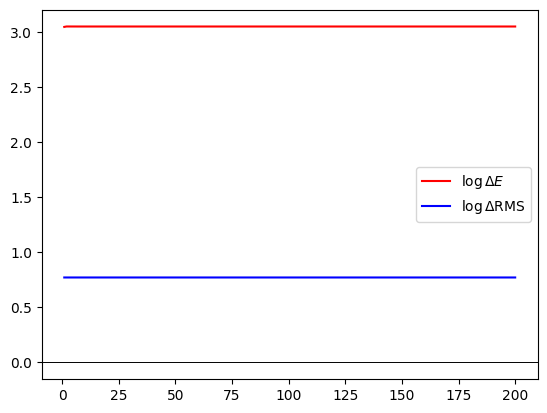

In [59]:
dist = np.linspace(1, iterations, iterations)
plt.plot(dist, e_conv, color = 'red', linestyle='-', label='$\\log{\\Delta E}$')
plt.plot(dist, d_conv, color = 'blue', linestyle='-', label='$\\log{\\Delta\\text{RMS}}$')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
plt.legend()